# Smoke test 06: analytic spectrum-fitting plumbing

This notebook was moved out of `notebooks/validation` because it uses an analytic stellar continuum. It is useful for fast plumbing checks, not real scientific validation.

# JAX-CIGALE spectrum fitting validation

This notebook is a first spectrum-fitting audit for the experimental JAX-CIGALE path.

The goal is not to prove the astrophysics yet. The goal is to verify the data flow that will matter for spectra:

1. create a known mock spectrum in observed-frame `f_lambda`;
2. apply an explicit instrumental line-spread function;
3. integrate the model into observed spectral pixels;
4. mask bad wavelength regions;
5. fit the mock with NUTS;
6. report physical parameters and posterior predictive residuals.

The model is deliberately lightweight here: analytic stellar continuum + attenuation + IGM + redshift. This keeps the notebook fast and makes the spectral likelihood machinery easy to audit before we switch the same machinery to DSPS/Cue spectra.

In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from sedinfer.experimental.jaxcigale import (
    GaussianSpectralData,
    JaxFilterSet,
    JaxParameterSpace,
    UniformJaxPrior,
    analytic_stellar_module,
    build_jax_sed_model,
    calzetti_attenuation_module,
    madau_igm_module,
    model_spectrum_on_observed_pixels,
    pixel_edges_from_centers_numpy,
    redshift_module,
    run_numpyro_nuts,
)

plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.grid": True})

def find_repo_root(start):
    path = Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "sedinfer").is_dir() and (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate the sedinfer repository root.")

REPO_ROOT = find_repo_root(Path.cwd())
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "jaxcigale_spectrum_fitting_validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_FILE = OUTPUT_DIR / "nuts_spectrum_fit.npz"
SUMMARY_FILE = OUTPUT_DIR / "nuts_spectrum_fit_summary.json"

RUN_NUTS = not FIT_FILE.exists()
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
print("Output directory:", OUTPUT_DIR)
print("Run NUTS in this execution:", RUN_NUTS)

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/jaxcigale_spectrum_fitting_validation
Run NUTS in this execution: True


## Build the spectral model

The model emits an observed-frame spectrum after redshifting and luminosity-distance dilution.

Units:

- rest wavelength grid: Angstrom;
- luminosity density before redshift: `Lsun / Angstrom`;
- observed spectrum after redshift: `erg s^-1 cm^-2 Angstrom^-1`;
- mass normalization: `10**log10_mass` is applied once inside `JaxSedModel.run_modules_mass_scaled`.

In [2]:
# Rest-frame wavelength grid. Keep it modest: the transparent Gaussian LSF is O(N^2).
wave_rest_a = np.linspace(900.0, 12000.0, 700)

# The model currently requires a filter set even for spectrum-only likelihoods.
# This dummy filter is not used in the spectral log likelihood.
dummy_filter_wave = np.linspace(4000.0, 9000.0, 64)
filters = JaxFilterSet.from_curves(["dummy"], [dummy_filter_wave], [np.ones_like(dummy_filter_wave)])

parameter_names = ["log10_mass", "z", "logzsol", "dust2", "dust_slope", "uv_bump"]
parameter_space = JaxParameterSpace(
    names=parameter_names,
    priors={
        "log10_mass": UniformJaxPrior(9.0, 11.2),
        "z": UniformJaxPrior(0.05, 0.60),
        "logzsol": UniformJaxPrior(-1.2, 0.30),
        "dust2": UniformJaxPrior(0.0, 1.0),
        "dust_slope": UniformJaxPrior(-0.6, 0.3),
        "uv_bump": UniformJaxPrior(0.0, 2.5),
    },
)

model = build_jax_sed_model(
    modules=[
        analytic_stellar_module(),
        calzetti_attenuation_module(),
        madau_igm_module(),
        redshift_module(),
    ],
    wavelength_grid_a=wave_rest_a,
    filters=filters,
    parameter_space=parameter_space,
)

true_theta = np.array([10.15, 0.28, -0.45, 0.32, -0.18, 0.6])
initial_theta = np.array([10.0, 0.25, -0.30, 0.25, -0.10, 0.4])

pd.DataFrame({"parameter": parameter_names, "truth": true_theta, "initial": initial_theta})

,parameter,truth,initial
0,log10_mass,10.15,10.00
1,z,0.28,0.25
2,logzsol,-0.45,-0.30
3,dust2,0.32,0.25
4,dust_slope,-0.18,-0.10
5,uv_bump,0.60,0.40


## Make an observed mock spectrum

The mock is produced from the same high-resolution model used for fitting. Then we apply the instrumental comparison step:

1. broaden the model spectrum with a Gaussian LSF at constant resolving power;
2. integrate the broadened model into observed wavelength pixels;
3. add Gaussian noise;
4. mask a few wavelength windows that mimic sky/telluric/bad calibration regions.

The likelihood will apply the exact same LSF and pixel integration to every proposed model before computing residuals.

In [3]:
rng = np.random.default_rng(7)

# Observed spectral pixels and instrumental resolution.
spectral_wave_a = np.linspace(3800.0, 9300.0, 260)
spectral_edges_a = pixel_edges_from_centers_numpy(spectral_wave_a)
resolving_power = 900.0

state_true = model.run_modules_mass_scaled(jnp.asarray(true_theta))
true_flux_pixel = np.asarray(
    model_spectrum_on_observed_pixels(
        state_true.wave_obs_a,
        state_true.flux_lambda_cgs,
        jnp.asarray(spectral_wave_a),
        jnp.asarray(spectral_edges_a),
        resample_mode="bin",
        resolving_power=resolving_power,
    )
)

# Noise model: 4 percent relative uncertainty plus a small floor so faint blue pixels stay finite.
noise_floor = 0.015 * np.nanmedian(true_flux_pixel)
sigma_flux = 0.04 * np.abs(true_flux_pixel) + noise_floor
observed_flux = true_flux_pixel + rng.normal(0.0, sigma_flux)

mask = np.ones_like(spectral_wave_a, dtype=bool)
for lo, hi in [(5550.0, 5605.0), (6280.0, 6340.0), (7580.0, 7700.0), (8900.0, 9000.0)]:
    mask &= ~((spectral_wave_a >= lo) & (spectral_wave_a <= hi))

spectral_data = GaussianSpectralData(
    wavelength_obs_a=spectral_wave_a,
    flux_lambda_cgs=observed_flux,
    sigma_lambda_cgs=sigma_flux,
    mask=mask,
    pixel_edges_obs_a=spectral_edges_a,
    resolving_power=resolving_power,
    resample_mode="bin",
)

print(f"Pixels: {spectral_wave_a.size}")
print(f"Active pixels after masks: {mask.sum()}")
print(f"Resolving power used in likelihood: R={resolving_power:.0f}")

Pixels: 260
Active pixels after masks: 246
Resolving power used in likelihood: R=900


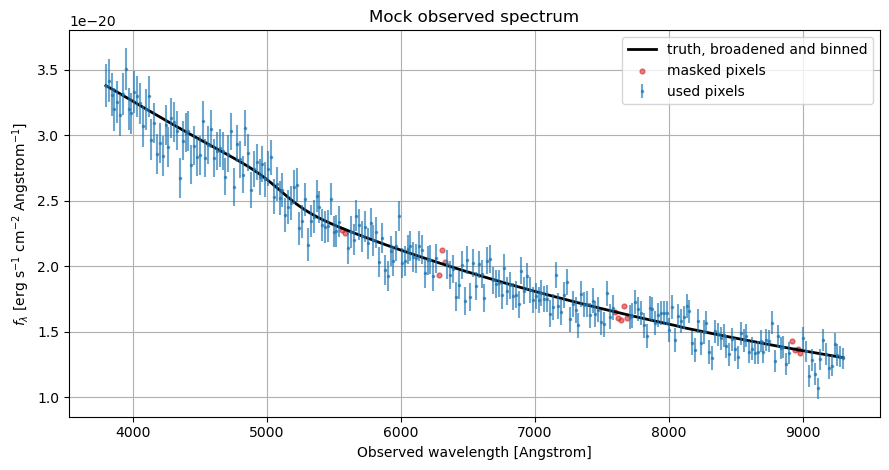

In [4]:
fig, ax = plt.subplots()
ax.plot(spectral_wave_a, true_flux_pixel, color="black", lw=2, label="truth, broadened and binned")
ax.errorbar(spectral_wave_a[mask], observed_flux[mask], yerr=sigma_flux[mask], fmt=".", ms=3, alpha=0.65, label="used pixels")
ax.scatter(spectral_wave_a[~mask], observed_flux[~mask], s=12, color="tab:red", alpha=0.6, label="masked pixels")
ax.set_xlabel("Observed wavelength [Angstrom]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title("Mock observed spectrum")
ax.legend(loc="best")
fig.tight_layout()

## LSF and pixel-bin sanity check

This is not the galaxy fit. It is a toy narrow line showing why the likelihood bins the model after broadening. Point interpolation and pixel averaging are not equivalent when a line is narrower than a pixel.

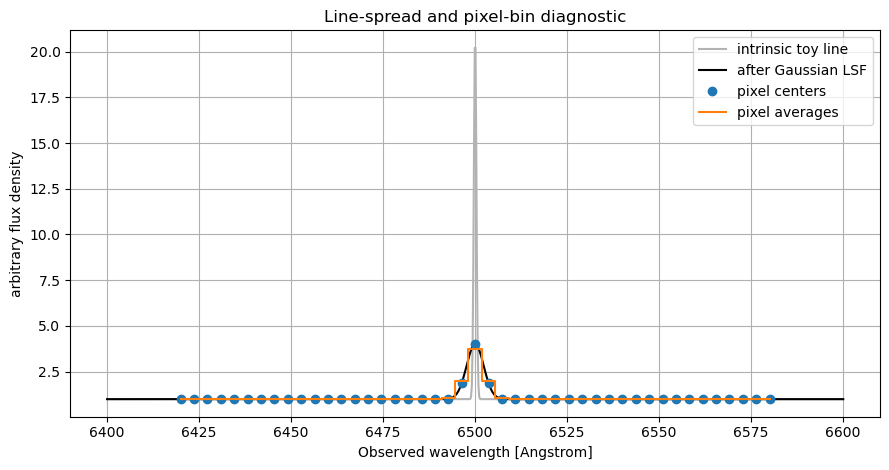

In [5]:
from sedinfer.experimental.jaxcigale import gaussian_lsf_smooth_observed, bin_average_spectrum

line_wave = jnp.asarray(np.linspace(6400.0, 6600.0, 1000))
line_flux = 1.0 + 20.0 * jnp.exp(-0.5 * ((line_wave - 6500.0) / 0.35) ** 2)
line_centers = np.linspace(6420.0, 6580.0, 45)
line_edges = pixel_edges_from_centers_numpy(line_centers)
line_smooth = gaussian_lsf_smooth_observed(line_wave, line_flux, resolving_power=1200.0)
line_interp = np.asarray(jnp.interp(jnp.asarray(line_centers), line_wave, line_smooth))
line_binned = np.asarray(bin_average_spectrum(line_wave, line_smooth, jnp.asarray(line_edges)))

fig, ax = plt.subplots()
ax.plot(np.asarray(line_wave), np.asarray(line_flux), color="0.7", label="intrinsic toy line")
ax.plot(np.asarray(line_wave), np.asarray(line_smooth), color="black", label="after Gaussian LSF")
ax.plot(line_centers, line_interp, "o", label="pixel centers")
ax.step(line_centers, line_binned, where="mid", label="pixel averages")
ax.set_xlabel("Observed wavelength [Angstrom]")
ax.set_ylabel("arbitrary flux density")
ax.set_title("Line-spread and pixel-bin diagnostic")
ax.legend(loc="best")
fig.tight_layout()

## Fit with NUTS

The NUTS target is the vector of physical parameters listed above. The spectrum object carries the mask, LSF, pixel edges, and resampling mode.

If `nuts_spectrum_fit.npz` already exists, the notebook loads it instead of rerunning the sampler.

In [6]:
if RUN_NUTS:
    t0 = time.perf_counter()
    nuts_result = run_numpyro_nuts(
        model=model,
        data=spectral_data,
        initial_theta=jnp.asarray(initial_theta),
        num_warmup=80,
        num_samples=120,
        rng_seed=11,
        progress_bar=True,
        target_accept_prob=0.78,
        max_tree_depth=7,
        dense_mass=True,
    )
    runtime = time.perf_counter() - t0
    np.savez(
        FIT_FILE,
        samples=nuts_result.samples,
        log_prob=nuts_result.log_prob,
        theta_names=np.asarray(nuts_result.theta_names),
        truth=true_theta,
        initial=initial_theta,
        spectral_wave_a=spectral_wave_a,
        spectral_edges_a=spectral_edges_a,
        observed_flux=observed_flux,
        sigma_flux=sigma_flux,
        mask=mask,
        true_flux_pixel=true_flux_pixel,
        resolving_power=np.asarray(resolving_power),
        runtime_seconds=np.asarray(runtime),
    )
    extra = nuts_result.extra_fields.get("numpyro", {})
    summary = {
        "runtime_seconds": float(runtime),
        "n_samples": int(nuts_result.samples.shape[0]),
        "jax_backend": jax.default_backend(),
        "accept_prob_mean": float(np.mean(np.asarray(extra.get("accept_prob", np.nan)))),
        "n_divergences": int(np.sum(np.asarray(extra.get("diverging", [])))) if "diverging" in extra else None,
    }
    SUMMARY_FILE.write_text(json.dumps(summary, indent=2))
else:
    print("Loading existing fit", FIT_FILE)

fit = np.load(FIT_FILE, allow_pickle=True)
samples = fit["samples"]
log_prob = fit["log_prob"]
theta_names = [str(x) for x in fit["theta_names"]]
truth = fit["truth"]
runtime = float(fit["runtime_seconds"])

print(f"Loaded samples: {samples.shape}")
print(f"Runtime: {runtime:.2f} s")
if SUMMARY_FILE.exists():
    print(SUMMARY_FILE.read_text())

  0%|          | 0/200 [00:00<?, ?it/s]

warmup:   5%|▌         | 10/200 [00:00<00:16, 11.59it/s, 7 steps of size 4.90e-04. acc. prob=0.47]

warmup:  10%|█         | 20/200 [00:01<00:16, 10.97it/s, 127 steps of size 2.96e-03. acc. prob=0.64]

warmup:  15%|█▌        | 30/200 [00:02<00:13, 12.43it/s, 127 steps of size 1.63e-03. acc. prob=0.67]

warmup:  20%|██        | 40/200 [00:03<00:12, 12.89it/s, 127 steps of size 3.37e-03. acc. prob=0.70]

...

sample:  90%|█████████ | 180/200 [00:10<00:01, 19.47it/s, 127 steps of size 1.44e-01. acc. prob=0.83]

sample:  95%|█████████▌| 190/200 [00:11<00:00, 17.60it/s, 31 steps of size 1.44e-01. acc. prob=0.83] 

sample: 100%|██████████| 200/200 [00:11<00:00, 17.84it/s, 95 steps of size 1.44e-01. acc. prob=0.83]

sample: 100%|██████████| 200/200 [00:11<00:00, 16.70it/s, 95 steps of size 1.44e-01. acc. prob=0.83]

Loaded samples: (120, 6)
Runtime: 17.87 s
{
  "runtime_seconds": 17.86638725013472,
  "n_samples": 120,
  "jax_backend": "cpu",
  "accept_prob_mean": 0.8290360901932845,
  "n_divergences": 0
}


In [7]:
rows = []
for i, name in enumerate(theta_names):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    rows.append({
        "parameter": name,
        "truth": truth[i],
        "median": q50,
        "q16": q16,
        "q84": q84,
        "median_minus_truth": q50 - truth[i],
    })
summary_table = pd.DataFrame(rows)
summary_table

,parameter,truth,median,q16,q84,median_minus_truth
0,log10_mass,10.15,10.159328,10.084552,10.259396,0.009328
1,z,0.28,0.290599,0.272107,0.317262,0.010599
2,logzsol,-0.45,-0.528659,-0.785984,-0.348566,-0.078659
3,dust2,0.32,0.240488,0.166043,0.318499,-0.079512
4,dust_slope,-0.18,-0.312226,-0.502552,0.074544,-0.132226
5,uv_bump,0.60,0.873875,0.261471,1.647843,0.273875


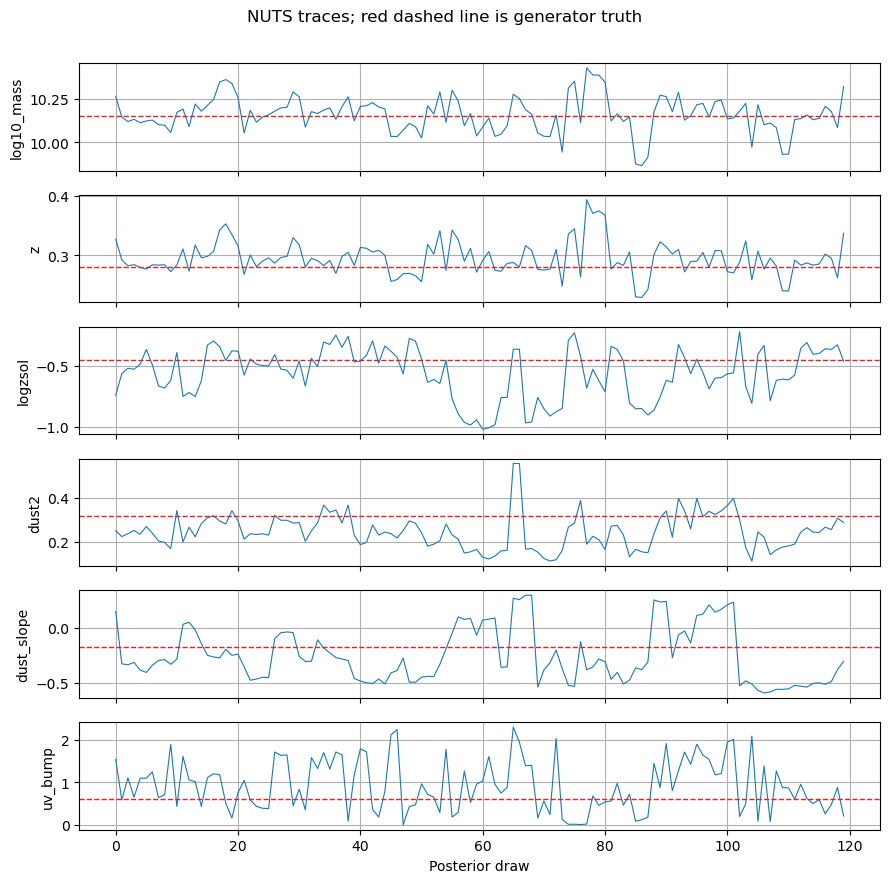

In [8]:
n_param = len(theta_names)
fig, axes = plt.subplots(n_param, 1, figsize=(9, 1.45 * n_param), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(samples[:, i], lw=0.8)
    ax.axhline(truth[i], color="tab:red", ls="--", lw=1)
    ax.set_ylabel(theta_names[i])
axes[-1].set_xlabel("Posterior draw")
fig.suptitle("NUTS traces; red dashed line is generator truth", y=1.01)
fig.tight_layout()

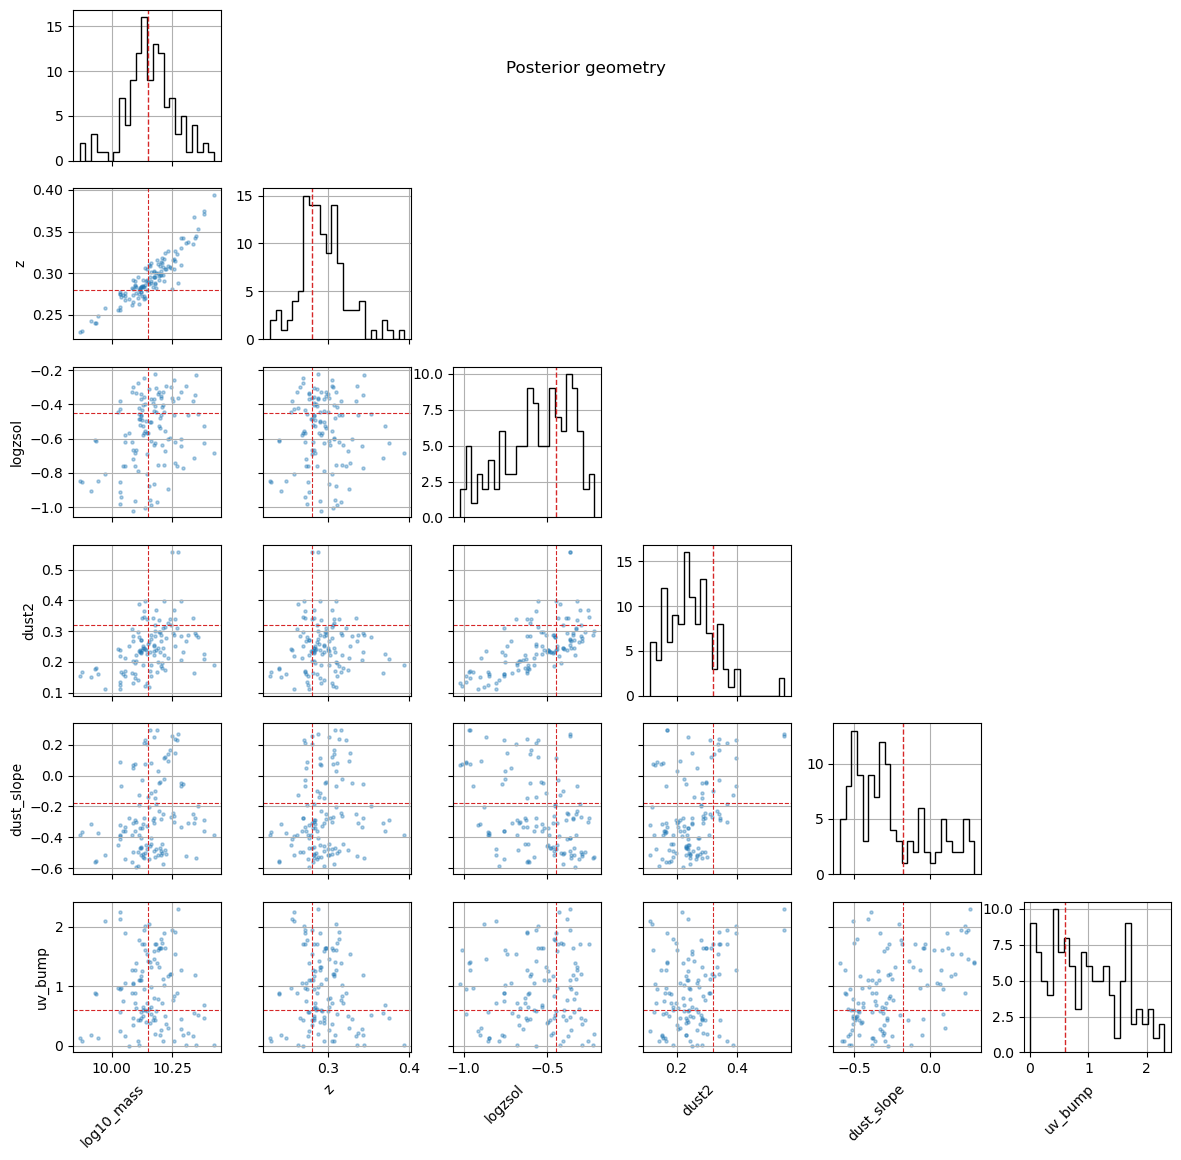

In [9]:
# Compact corner-style diagnostic without requiring the external corner package.
fig, axes = plt.subplots(n_param, n_param, figsize=(2.0 * n_param, 2.0 * n_param))
for i in range(n_param):
    for j in range(n_param):
        ax = axes[i, j]
        if i == j:
            ax.hist(samples[:, i], bins=24, histtype="step", color="black")
            ax.axvline(truth[i], color="tab:red", ls="--", lw=1)
        elif i > j:
            ax.scatter(samples[:, j], samples[:, i], s=5, alpha=0.35)
            ax.axvline(truth[j], color="tab:red", ls="--", lw=0.8)
            ax.axhline(truth[i], color="tab:red", ls="--", lw=0.8)
        else:
            ax.axis("off")
        if i == n_param - 1 and j <= i:
            ax.set_xlabel(theta_names[j], rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
        if j == 0 and i > 0:
            ax.set_ylabel(theta_names[i])
        elif i != j:
            ax.set_yticklabels([])
fig.suptitle("Posterior geometry", y=0.92)
fig.tight_layout()

## Posterior predictive spectrum

For each posterior draw we rerun the full model and then apply the same spectral response as the likelihood: resolving power, pixel edges, and mask. The residual panel is therefore in data-pixel space.

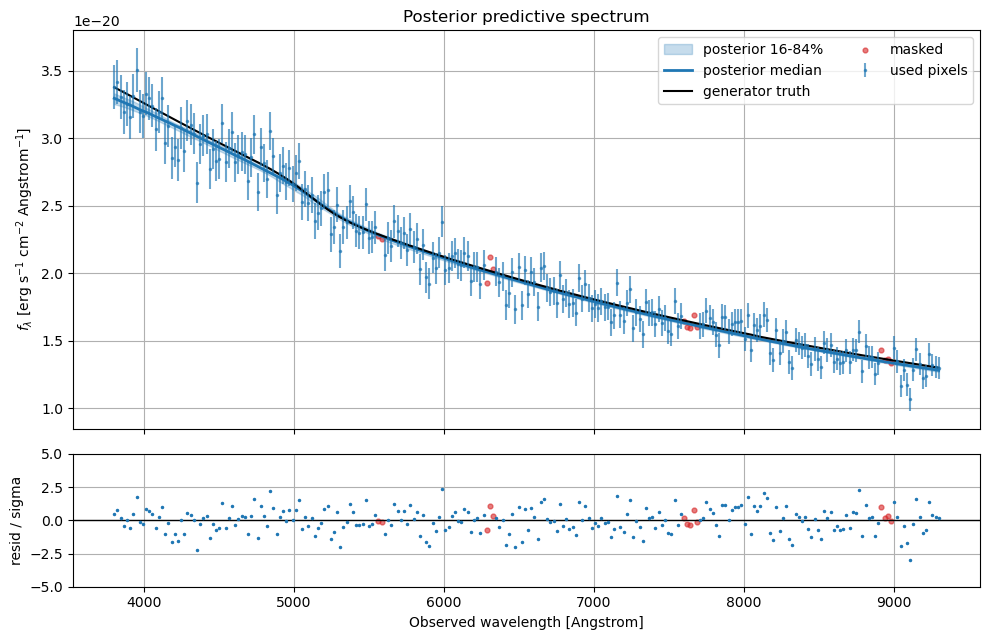

In [10]:
def pixel_model_for_theta(theta):
    state = model.run_modules_mass_scaled(jnp.asarray(theta))
    return np.asarray(
        model_spectrum_on_observed_pixels(
            state.wave_obs_a,
            state.flux_lambda_cgs,
            jnp.asarray(spectral_wave_a),
            jnp.asarray(spectral_edges_a),
            resample_mode="bin",
            resolving_power=resolving_power,
        )
    )

posterior_subset = samples[np.linspace(0, samples.shape[0] - 1, min(60, samples.shape[0]), dtype=int)]
pred = np.asarray([pixel_model_for_theta(theta) for theta in posterior_subset])
pred_q16, pred_q50, pred_q84 = np.percentile(pred, [16, 50, 84], axis=0)
truth_pixel = pixel_model_for_theta(truth)

residual_sigma = (observed_flux - pred_q50) / sigma_flux

fig, (ax, rx) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.fill_between(spectral_wave_a, pred_q16, pred_q84, color="tab:blue", alpha=0.25, label="posterior 16-84%")
ax.plot(spectral_wave_a, pred_q50, color="tab:blue", lw=2, label="posterior median")
ax.plot(spectral_wave_a, truth_pixel, color="black", lw=1.5, label="generator truth")
ax.errorbar(spectral_wave_a[mask], observed_flux[mask], yerr=sigma_flux[mask], fmt=".", ms=3, alpha=0.65, label="used pixels")
ax.scatter(spectral_wave_a[~mask], observed_flux[~mask], s=12, color="tab:red", alpha=0.6, label="masked")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.legend(loc="best", ncol=2)
ax.set_title("Posterior predictive spectrum")

rx.axhline(0.0, color="black", lw=1)
rx.plot(spectral_wave_a[mask], residual_sigma[mask], ".", ms=3)
rx.scatter(spectral_wave_a[~mask], residual_sigma[~mask], s=12, color="tab:red", alpha=0.6)
rx.set_xlabel("Observed wavelength [Angstrom]")
rx.set_ylabel("resid / sigma")
rx.set_ylim(-5, 5)
fig.tight_layout()

In [11]:
active_residual = residual_sigma[mask]
metrics = {
    "n_active_pixels": int(mask.sum()),
    "median_abs_residual_sigma": float(np.median(np.abs(active_residual))),
    "rms_residual_sigma": float(np.sqrt(np.mean(active_residual**2))),
    "max_abs_residual_sigma": float(np.max(np.abs(active_residual))),
    "runtime_seconds": runtime,
}
metrics

{'n_active_pixels': 246,
 'median_abs_residual_sigma': 0.631994207106712,
 'rms_residual_sigma': 0.9346090565379646,
 'max_abs_residual_sigma': 3.013232171953645,
 'runtime_seconds': 17.86638725013472}

## Checklist

Data entering the likelihood:

- `spectral_wave_a`: observed-frame pixel centers in Angstrom.
- `spectral_edges_a`: observed-frame pixel edges in Angstrom.
- `observed_flux`: observed `f_lambda` in cgs per Angstrom.
- `sigma_flux`: one-sigma uncertainty in the same units.
- `mask`: bad pixels and sky/telluric windows are excluded.

Transformations before comparison:

- model rest luminosity is redshifted and divided by luminosity distance;
- `10**log10_mass` is applied once;
- model is Gaussian-broadened at the requested resolving power;
- broadened model is integrated over observed spectral pixels;
- Gaussian residuals are computed only where `mask=True`.

Most important code paths to check:

- `sedinfer.experimental.jaxcigale.spectroscopy.model_spectrum_on_observed_pixels`;
- `sedinfer.experimental.jaxcigale.spectroscopy.gaussian_lsf_smooth_observed`;
- `sedinfer.experimental.jaxcigale.spectroscopy.bin_average_spectrum`;
- `GaussianSpectralData` construction;
- `JaxSedModel._spectral_log_likelihood_from_state`.

Known limitation of this first notebook:

- The generator is the same model as the fitter, so this validates inference machinery rather than model realism.
- The LSF is a single Gaussian prescription. Real spectra will need wavelength-dependent LSFs, velocity broadening, and calibration nuisance parameters.
- The stellar model here is analytic for speed. The same spectral likelihood should next be run with DSPS/Cue and then against CIGALE/FSPS mock spectra.